In [94]:
# --- IMPORT STATEMENTS ---

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.optimize import curve_fit
from scipy.stats import spearmanr

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve

In [ ]:
# --- GLOBAL VARIABLES ---
SAVE_FIGS = True
MASKED = True
MASKLOWER = True
LOWERMASK_THRESHOLD = 5
FULLMAPTHRES = 0.0

# GDIGs only
# L_BOUNDS = [16.26, 32.26] # degrees
# B_BOUNDS = [-1.46, 1.44] # degrees

L_BOUNDS = [20, 40] # degrees
B_BOUNDS = [-1.4, 1.4] # degrees

DEGREES_PER_REGIONL = 2.0 # for lattice TT plots (change as desired)
DEGREES_PER_REGIONB = 2.8 # for lattice TT plots (change as desired)

SMOOTHING_FWHM = 5 # arcmin
REBIN_FACTOR = 5

# LINUX_DIRECTORY = '/home/aimee/mphys' # Aimee
LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/maps' # Aimee
MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe
# MASKED_MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/masked_maps' # Aimee
MASKED_MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/masked_maps' # Joe
# FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures' # Aimee
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures/maps_and_TTplots' # Joe
CSV_SAVEDIR = f'{LINUX_DIRECTORY}/results_files/longitude_intercept_fits'

# MAPS

# Beam widths? (GET TRUE VALUES FOR ALL MAPS)
COMAP_FWHM = 4.5
EFFELSBERG_FWHM = 4.3
GDIGS_FWHM = 2.65 # TEMP
NOBEYAMA_FWHM = 2.66 # TEMP
PARKES_FWHM = 4.1 # TEMP
SINO_GERMAN_FWHM = 9.9999 # TEMP
AKARI_FWHM = 4.9999 # TEMP
AMI_FWHM = 4.9999

# Fractional errors (GET TRUE VALUES FOR ALL MAPS)
COMAP_ERR = 0.05
EFFELSBERG_ERR = 0.1
GDIGS_ERR = 0.1 # TEMP - CHECK!
NOBEYAMA_ERR = 0.1 # TEMP
PARKES_ERR = 0.1 # TEMP
SINO_GERMAN_ERR = 0.1 # TEMP
AKARI_ERR = 0.1 # TEMP
AMI_ERR = 0.02

# Zero indexed hdu layer for noise
COMAP_NOISELAYER = 2
EFFELSBERG_NOISELAYER = 2
GDIGS_NOISELAYER = 2
NOBEYAMA_NOISELAYER = 2
PARKES_NOISELAYER = 2
SINO_GERMAN_NOISELAYER = 2
AKARI_NOISELAYER = 2
AMI_NOISELAYER = 2

# Zero indexed hdu layer for noise
COMAP_RAWNOISELAYER = 1
EFFELSBERG_RAWNOISELAYER = 1
GDIGS_RAWNOISELAYER = 1
NOBEYAMA_RAWNOISELAYER = 1
PARKES_RAWNOISELAYER = 1
SINO_GERMAN_RAWNOISELAYER = 1
AKARI_RAWNOISELAYER = 1
AMI_RAWNOISELAYER = 1

ELECTRON_TEMP = 8000
# Maps and their frequencies


COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_alr-2_galactic_301025_band00_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_alr-2_galactic_301025_band01_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_alr-2_galactic_301025_band02_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_alr-2_galactic_301025_band03_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_alr-2_galactic_301025_band04_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_alr-2_galactic_301025_band05_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_alr-2_galactic_301025_band06_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_alr-2_galactic_301025_band07_feed01-02-03-04-05-06-07-08-09-10-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}


# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 1.43 GHz (10')" : ["EFFELSBERG-1.4285714285714286GHz-10.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (15')" : ["EFFELSBERG-1.4285714285714286GHz-15.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (20')" : ["EFFELSBERG-1.4285714285714286GHz-20.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (25')" : ["EFFELSBERG-1.4285714285714286GHz-25.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (30')" : ["EFFELSBERG-1.4285714285714286GHz-30.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (60')" : ["EFFELSBERG-1.4285714285714286GHz-60.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 2.73 GHz (5')" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits", 2.7272727272727275e9],
    "Effelsberg 2.73 GHz (5')" : ["Effelsberg_2.7272GHz_raw_1arcmin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (10')" : ["EFFELSBERG-2.7272727272727275GHz-10.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (15')" : ["EFFELSBERG-2.7272727272727275GHz-15.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (20')" : ["EFFELSBERG-2.7272727272727275GHz-20.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (25')" : ["EFFELSBERG-2.7272727272727275GHz-25.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (30')" : ["EFFELSBERG-2.7272727272727275GHz-30.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (60')" : ["EFFELSBERG-2.7272727272727275GHz-60.0amin.fits", 2.7272727272727275e9]
}

GDIGS_MAPS = { # name : [file name, frequency / Hz]
    # Note to self: create a GDIGS mosaic smoothed to 5 arcmin?
    "GDIGS Moment 0" : ["gdigs_moment0_mosaic_1arcmin.fits", 5.76e9] # CHECK GDIGS FREQUENCY
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
    # "Nobeyama 10.0GHz (5 amin)" : ["NOBEYAMA-10.0GHz-5.0amin.fits", 10.3e9]
    "Nobeyama 10.0GHz (5 amin)" : ["Nobeyama_10.0GHz_raw_1arcmin.fits", 10.3e9]
    # "Nobeyama 10.0GHz (10 amin)"  : ["NOBEYAMA-10.0GHz-10.0amin.fits", 9.4e9]
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    "PARKES 5GHz (5')" : ["Parkes_5.0GHz_raw_1arcmin.fits", 5e9],
    # "PARKES 5GHz (10')" : ["PARKES-5.0GHz-10.0amin.fits", 5e9]
}


SINO_GERMAN_MAPS = { # name : [file name, frequency / Hz]
    "Sino German 5.0GHz (10 amin)" : ["SinoGermanSurvey-5.0GHz-10.0amin.fits", 5e9]
}

AKARI_MAPS = { # name : [file name, frequency / Hz]
    # "Akari 1875 GHz (5 amin)" : ["AKARI-1874.9999999999998GHz-5.0amin.fits", 1874.9999999999998e9],
    "Akari 1875 GHz (10')" : ["AKARI-1874.9999999999998GHz-10.0amin.fits", 1874.9999999999998e9],
    # "Akari 2143 GHz (5 amin)" : ["AKARI-2142.857142857143GHz-5.0amin.fits", 2142.857142857143e9],
    "Akari 2143 GHz (10')" : ["AKARI-2142.857142857143GHz-10.0amin.fits", 2142.857142857143e9],
    # "Akari 3333 GHz (5 amin)" : ["AKARI-3333.333333333333GHz-5.0amin.fits", 3333.333333333333e9],
    "Akari 3333 GHz (10')" : ["AKARI-3333.333333333333GHz-10.0amin.fits", 3333.333333333333e9],
    # "Akari 4615 GHz (5 amin)" : ["AKARI-4615.384615384616GHz-5.0amin.fits", 4615.384615384616e9],
    "Akari 4615 GHz (10')" : ["AKARI-4615.384615384616GHz-10.0amin.fits", 4615.384615384616e9]
}

AMI_MAPS = {
    "AMI 15.7 GHz (5')": ["AMI-15.7GHz-5.0amin.fits", 15.7e9]
    # "AMI 15.7 GHz (10')":
}

BOLOCAM_MAPS = {} # CORRUPTED

CGPS_MAPS = {} # CORRUPTED

CHIPASS_MAPS = {}

IRIS_MAPS = {}


In [96]:
# --- FUNCTION DEFINITIONS ---

In [97]:
# --- MAPS PROCESSING ---

In [98]:
def gaunt_factor(freq, elec_temp):
    pi = constants.pi
    e = 2.718281828
    exponent = 5.96 - ((np.sqrt(3)/pi) * np.log((freq/(10**(9)) * (elec_temp*(10**4))**(-1.5))))
    # print(e**exponent)
    # print(e)
    return np.log(e**(exponent) + e)

In [99]:
gaunt_factor(5.7e9, ELECTRON_TEMP)

np.float64(20.049672827972888)

In [100]:
def intrrl_to_cont(intrrl, freq, elec_temp):
    denominator = 1.0534*(10**4) * ((freq/(10**9)) / (elec_temp * gaunt_factor(freq, elec_temp)))
    return (intrrl)/(denominator)

In [101]:
def get_map(path, noise_layer=1, rawnoise_layer=1):
    
    # print(f"\nGetting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    try:
        noise = fits_file[noise_layer].data
    except Exception as E:
        print(f"Could not get processed noise layer from {path} for the following reason: \n{E}")
        noise = np.zeros_like(data) + 0.01
    try:
        rawnoise = fits_file[rawnoise_layer].data
    except Exception as E:
        print(f"Could not get raw noise layer from {path} for the following reason: \n{E}")
        rawnoise = np.zeros_like(data) + 0.01
    header = fits_file[0].header
    wcs = WCS(header)
        
    return data, noise, rawnoise, header, wcs

In [102]:
def get_map_info(map_title):
    
    if map_title in COMAP_MAPS.keys():
        fname = COMAP_MAPS[map_title][0]
        freq = COMAP_MAPS[map_title][1]
        fwhm = COMAP_FWHM
        err = COMAP_ERR
        noiselayer = COMAP_NOISELAYER
        rawnoiselayer = COMAP_RAWNOISELAYER
    elif map_title in EFFELSBERG_MAPS.keys():
        fname = EFFELSBERG_MAPS[map_title][0]
        freq = EFFELSBERG_MAPS[map_title][1]
        if map_title == "Effelsberg 2.73 GHz (5')":
            fwhm = EFFELSBERG_FWHM
        elif map_title == "Effelsberg 1.43 GHz (10')":
            fwhm = EFFELSBERG_FWHM*2
        else:
            print(f"No encoder for FWHM of {map_title}")
            raise EncodingWarning
        err = EFFELSBERG_ERR
        noiselayer = EFFELSBERG_NOISELAYER
        rawnoiselayer = EFFELSBERG_RAWNOISELAYER
    elif map_title in GDIGS_MAPS.keys():
        fname = GDIGS_MAPS[map_title][0]
        freq = GDIGS_MAPS[map_title][1]
        fwhm = GDIGS_FWHM
        err = GDIGS_ERR
        noiselayer = GDIGS_NOISELAYER
        rawnoiselayer = GDIGS_RAWNOISELAYER
    elif map_title in NOBEYAMA_MAPS.keys():
        fname = NOBEYAMA_MAPS[map_title][0]
        freq = NOBEYAMA_MAPS[map_title][1]
        fwhm = NOBEYAMA_FWHM
        err = NOBEYAMA_ERR
        noiselayer = NOBEYAMA_NOISELAYER
        rawnoiselayer = NOBEYAMA_RAWNOISELAYER
    elif map_title in PARKES_MAPS.keys():
        fname = PARKES_MAPS[map_title][0]
        freq = PARKES_MAPS[map_title][1]
        fwhm = PARKES_FWHM
        err = PARKES_ERR
        noiselayer = PARKES_NOISELAYER
        rawnoiselayer = PARKES_RAWNOISELAYER
    elif map_title in SINO_GERMAN_MAPS.keys():
        fname = SINO_GERMAN_MAPS[map_title][0]
        freq = SINO_GERMAN_MAPS[map_title][1]
        fwhm = SINO_GERMAN_FWHM
        err = SINO_GERMAN_ERR
        noiselayer = SINO_GERMAN_NOISELAYER
        rawnoiselayer = SINO_GERMAN_RAWNOISELAYER
    elif map_title in AKARI_MAPS.keys():
        fname = AKARI_MAPS[map_title][0]
        freq = AKARI_MAPS[map_title][1]
        fwhm = AKARI_FWHM
        err = AKARI_ERR
        noiselayer = AKARI_NOISELAYER
        rawnoiselayer = AKARI_RAWNOISELAYER
    elif map_title in AMI_MAPS.keys():
        fname = AMI_MAPS[map_title][0]
        freq = AMI_MAPS[map_title][1]
        fwhm = AMI_FWHM
        err = AMI_ERR
        noiselayer = AMI_NOISELAYER
        rawnoiselayer = AMI_RAWNOISELAYER

    
    # (ADD MORE MAPS AS NECESSARY)
    
    else:
        print(f'Error extracting map details for {map_title}')
        return None, None, None, None, None, None

    return fname, freq, fwhm, err, noiselayer, rawnoiselayer

In [103]:
def convert_to_mK(map_title, map, noise, rawnoise, map_freq):
    
    # COMAP and GDIGS in K
    if map_title in COMAP_MAPS.keys():
        map_mK = np.array(map) * 1000 # K to mK
        noise_mK = np.array(noise) * 1000 # K to mK
        rawnoise_mK = np.array(rawnoise) * 1000 # K to mK
    
    # elif map_title in GDIGS_MAPS.keys():
    #     map_mK = intrrl_to_cont(np.array(map), map_freq, ELECTRON_TEMP) * 1000
    elif map_title in GDIGS_MAPS.keys():
        map_mK = np.array(map) * 1000
        noise_mK = np.array(noise)
        rawnoise_mK = np.array(rawnoise)
    
    # All other maps in Jy/sr (CHECK WHENEVER ADD NEW MAPS!)
    # else: 
    #     map_K = JyPersr_to_K(np.array(map), map_freq) # Jy/sr to K
    #     map_mK = np.array(map_K) * 1000 # K to mK
    #     noise_mK = np.array(noise)
    #     rawnoise_mK = np.array(rawnoise)
    else:
        map_mK = np.array(map)
        noise_mK = np.array(noise)
        rawnoise_mK = np.array(rawnoise)
    
    return map_mK, noise_mK, rawnoise_mK

In [104]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [105]:
def cut_data(data, wcs, header, l_bounds=L_BOUNDS, b_bounds=B_BOUNDS):
    
    lat_min, lat_max = b_bounds[0], b_bounds[1]
    long_min, long_max = l_bounds[0], l_bounds[1]

    step = header['CDELT2']  # pixel resolution

    # may be off by fraction of pixel
    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row

    new_header = header.copy()
    new_header['CRPIX1'] = wcs.wcs.crpix[0]
    new_header['CRPIX2'] = wcs.wcs.crpix[1]
    
    new_wcs = WCS(new_header)

    return submap, new_wcs, new_header


In [106]:
def rebin_array(data, factor):
    n_rows, n_cols = data.shape
    # print(f"Original shape: {data.shape}")

    # Crop rows and columns if not divisible by factor
    if n_rows % factor != 0:
        new_n_rows = (n_rows // factor) * factor
        data = data[:new_n_rows, :]
        # print(f"Adjusted rows to: {new_n_rows}")
    if n_cols % factor != 0:
        new_n_cols = (n_cols // factor) * factor
        data = data[:, :new_n_cols]
        # print(f"Adjusted columns to: {new_n_cols}")

    # Reshape and average in blocks of factor x factor
    reshaped_data = data.reshape(data.shape[0] // factor, factor, data.shape[1] // factor, factor)
    rebinned_data = reshaped_data.mean(axis=(1, 3))  # If any pixel in block is nan, whole block is nan (good)
    # print(f"Re-shaped data to: {rebinned_data.shape}")
    
    return rebinned_data


# def rebin_map(data, wcs, factor):
    
#     l_min = L_BOUNDS[0]
#     l_max = L_BOUNDS[1]
#     b_min = B_BOUNDS[0]
#     b_max = B_BOUNDS[1]
#     step = wcs.wcs.cdelt[1] # pixel size in degrees

#     data = rebin_array(data, factor)

#     ny, nx = data.shape
#     cy, cx = ny // 2, nx // 2
#     # print(cy, cx)   

#     # Indices for cutout
#     new_wcs = wcs.copy()
#     new_wcs.wcs.crpix[0] = cx
#     new_wcs.wcs.crpix[1] = cy
#     new_wcs.wcs.cdelt[0] = -step * factor
#     new_wcs.wcs.cdelt[1] = step * factor
#     new_wcs.wcs.crval[0] = (l_min + l_max) / 2
#     new_wcs.wcs.crval[1] = (b_min + b_max) / 2

#     new_header = new_wcs.to_header()

#     return data, new_wcs, new_header


def rebin_map(data, header, factor):
    
    l_min = L_BOUNDS[0]
    l_max = L_BOUNDS[1]
    b_min = B_BOUNDS[0]
    b_max = B_BOUNDS[1]

    data = rebin_array(data, factor)

    ny, nx = data.shape
    cy, cx = ny // 2, nx // 2
    # print(cy, cx)   

    new_header = header.copy()
    new_header["CRPIX1"] = 1
    new_header["CRPIX2"] = 1
    new_header["CRVAL1"] = l_max
    new_header["CRVAL2"] = b_min
    new_header["CDELT1"] *= factor
    new_header["CDELT2"] *= factor
    new_header["LONPOLE"] = 180
    
    # Indices for cutout
    # new_wcs = wcs.copy()
    # new_wcs.wcs.crpix[0] = cx
    # new_wcs.wcs.crpix[1] = cy
    # new_wcs.wcs.cdelt[0] = -step * factor
    # new_wcs.wcs.cdelt[1] = step * factor
    # new_wcs.wcs.crval[0] = (l_min + l_max) / 2
    # new_wcs.wcs.crval[1] = (b_min + b_max) / 2
    # for k, v in new_header.items():
    #     print(f"{k}: {v}")
    new_wcs = WCS(new_header)

    return data, new_wcs, new_header

In [107]:
def JyPersr_to_K(inp, freq):
    
    k_B = constants.Boltzmann
    c = constants.speed_of_light
    Jy_to_SI = 1e-26

    factor = (c**2) / (2 * k_B * (freq**2)) * Jy_to_SI
    
    return factor * inp

In [108]:
def sigma(FWHM1, FWHM2, scale):
    
    sigma = np.sqrt(abs(FWHM1**2 - FWHM2**2)) / (2*np.sqrt(2 * np.log(2)) * scale)
    
    return sigma

In [109]:
def apply_lowermask(map, noise, header, region_sizel, region_size_b, threshold=3):
    degrees_per_pixel = header['CDELT2']
    # print(degrees_per_pixel)
    pixels_per_regionl = int(region_sizel / degrees_per_pixel)
    pixels_per_regionb = int(region_size_b / degrees_per_pixel)
    degrees_per_regionl = pixels_per_regionl * degrees_per_pixel # now accurate to rounded pixels_per_region
    degrees_per_regionb = pixels_per_regionb * degrees_per_pixel # now accurate to rounded pixels_per_region
    
    b_min, b_max = B_BOUNDS[0], B_BOUNDS[1]
    l_min, l_max = L_BOUNDS[0], L_BOUNDS[1]

    x_min = 0
    x_max = map.shape[1]
    y_min = 0
    y_max = map.shape[0]

    y_min_arr, b_min_arr = [], []
    for i in range(0, int(np.ceil((y_max - y_min) / pixels_per_regionb))):
        y_min_arr.append(y_min + i * pixels_per_regionb)
        b_min_arr.append(b_min + i * degrees_per_regionb)
    # y_min_arr = np.flip(y_min_arr)

    x_min_arr, l_min_arr = [], []
    for i in range(0, int(np.ceil((x_max - x_min) / pixels_per_regionl))):
        x_min_arr.append(x_min + i * pixels_per_regionl)
        l_min_arr.append(l_min + i * degrees_per_regionl)

    # print(f"Map shape: {map.shape}")
    # print(f"Noise shape: {noise.shape}")
    mask = np.zeros_like(map)
    sigmas_map = np.zeros_like(map)
    masked_map = map.copy()
    for i in range(0, len(y_min_arr)):
        y_min = y_min_arr[i]
        y_max = y_min + pixels_per_regionb

        b_min = np.flip(b_min_arr)[i]
        b_max = b_min + degrees_per_regionb
        
        for j in range(0, len(x_min_arr)):
            x_min = np.flip(x_min_arr)[j]
            x_max = x_min + pixels_per_regionl

            l_min = l_min_arr[j]
            l_max = l_min + degrees_per_regionl
            map_cut = map[y_min:y_max,x_min:x_max].copy()
            # print(f"Map TT cut shape: {map_cut.shape}")
            noise_cut = noise[y_min:y_max,x_min:x_max].copy()
            # print(f"Noise TT cut shape: {noise_cut.shape}")
            mask_cut = np.zeros_like(map_cut)
            mask_cut = np.where((map_cut-np.nanmin(map_cut))/noise_cut <= threshold, 0.0, 1.0)
            # print(mask_cut)
            # print(f"Mask cut shape: {mask_cut.shape}")
            mask[y_min:y_max,x_min:x_max] = mask_cut
            sigmas_map[y_min:y_max,x_min:x_max] = (map_cut-np.nanmin(map_cut))/noise_cut

    # plot_fits(mask, WCS(header))
    # plot_fits(sigmas_map, WCS(header))
    
    # print(mask)
    mask = np.where(map <= FULLMAPTHRES, 0.0, mask)
    masked_map = np.where(mask == 0.0, np.nan, masked_map)
    
    return masked_map

In [110]:
def process_map(map_title, masked=True):
    
    map_fname, map_freq, map_fwhm, map_err, map_noiselayer, map_rawnoiselayer = get_map_info(map_title)

    if masked:
        map, noise, rawnoise, header, wcs = get_map(f'{MASKED_MAPS_DIRECTORY}/{map_fname.replace(".fits", "")}_masked.fits', noise_layer=map_noiselayer, rawnoise_layer=map_rawnoiselayer)
        # plot_fits(map, wcs, title=f'{map_title} - masked')
    else:
        map, noise, rawnoise, header, wcs = get_map(f'{MAPS_DIRECTORY}/{map_fname}', noise_layer=map_noiselayer, rawnoise_layer=map_rawnoiselayer)
        # plot_fits(map, wcs, title=f'{map_title} - original')
    # factor = -10
    # if map_title == "GDIGS Moment 0":
    #     wcs.wcs.crval[0] -= 0.6
    #     header["CRVAL1"] -= 0.6
        # wcs.wcs.crpix[0] = 0.5
        # header["CRPIX1"] = 0.5
    
    print(wcs)

    # Convert to brigtness temperature [mK]
    map, noise, rawnoise = convert_to_mK(map_title, map, noise, rawnoise, map_freq)
    # print(unpack2D(noise))
    plot_fits(map, wcs, title=f'{map_title} - converted')
    # plot_fits(noise, wcs, title=f'{map_title} - converted')
    # plot_fits(rawnoise, wcs, title=f'{map_title} - converted')

    
    # plot_fits((map-np.min(map))/noise, wcs, title=f'{map_title} - converted')

    # if masked and MASKLOWER: # Mask values < 0 (Note to self: add brightness threshold in maksing code -> unnecessary?)
    #     threshold = LOWERMASK_THRESHOLD # mK
    #     map[np.where(map/noise - np.nanmin(map) <= threshold)] = np.nan
    noise[np.where(map == np.nan)] = np.nan
    rawnoise[np.where(map == np.nan)] = np.nan

    smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(map_fwhm, SMOOTHING_FWHM, 1))
    map_smooth = convolve(map, smoothing_kernel, preserve_nan=True)

    old_header = header.copy()
    old_wcs = wcs.copy()
    # Cut data to size
    map_smooth, wcs, header = cut_data(map_smooth, old_wcs, old_header)
    noise, _, _ = cut_data(noise, old_wcs, old_header)
    rawnoise, _, _ = cut_data(rawnoise, old_wcs, old_header)
    # print(unpack2D(noise))
    
    noise[map_smooth==np.nan] = np.nan
    rawnoise[map_smooth==np.nan] = np.nan
    
    # plot_fits(map, wcs, title=f'{map_title} - cut')
    # Smooth to 5 arcmin (doesn't change wcs/header)
    
    if MASKLOWER:
        map_smooth = apply_lowermask(map_smooth, rawnoise, header, DEGREES_PER_REGIONL, DEGREES_PER_REGIONB, threshold=LOWERMASK_THRESHOLD)
    # plot_fits(map_smooth, wcs, title=f'{map_title} - smoothed to 5 arcmin')
    # plot_fits(map_smooth, wcs, title=f'{map_title} - smoothed to 5 arcmin fully masked')

    # Repixellise to 5x5 bins (does change wcs/header)
    # map_repix, map_repix_wcs, map_repix_header = rebin_map(map_smooth, wcs, factor=REBIN_FACTOR) # using wcs
    map_repix, map_repix_wcs, map_repix_header = rebin_map(map_smooth, header, factor=REBIN_FACTOR) # using header
    # noise_repixsq, _, _ = rebin_map(noise**2, wcs, factor=REBIN_FACTOR) # using wcs
    noise_repixsq, _, _ = rebin_map(noise**2, header, factor=REBIN_FACTOR) # using header
    noise_repix = np.sqrt(noise_repixsq)
    # print(unpack2D(noise_repix))
    plot_fits(map_repix, map_repix_wcs, title=f'{map_title} - smoothed to {SMOOTHING_FWHM} arcmin and rebinned')
    # plot_fits(noise_repix, wcs, title=f'{map_title} noise - smoothed to 5 arcmin and rebinned')
    # Calculate errors
    # map_repix_errs = np.array(map_repix) * map_err

    return map_repix, noise_repix, map_err, map_freq, map_repix_wcs, map_repix_header

In [111]:
# --- TT PLOTTING ---

In [112]:
def unpack2D(arr):
    unpacked = []
    for row in arr:
        unpacked = np.append(unpacked, row)
    return unpacked

In [113]:
def linreg_model_odr(params, x):
    m = params[0]
    c = params[1]
    return m * x + c

In [114]:
def order4polynomial(x, a, b, c, d, e):
    return a*x**4 + b*x**3 + c*x**2 + d*x + e

In [115]:
def tt_scatter_odr(datax, datay, datax_unc, datay_unc, x_freq, y_freq):
    # Initial intercept guess
    try:
        c_initial = min(datay)
    except Exception as E:
        c_initial = 0.0
        print(f"Warning: {E}\nForced initial intercept value to 0.0")
    
    # # estimate gradient given expected spectral index of -2.1 (requires frequencies)
    # m_initial, _ = beta_to_gradient(-2.1, 0, x_freq, y_freq) 
    
    # OR: estimate gradient by diff_y/diff_x
    try:
        m_initial1 = (max(datay) - min(datay)) / (datax[np.argmax(datay)] - datax[np.argmin(datay)])
        m_initial2 = (datay[np.argmax(datax)] - datay[np.argmin(datax)]) / (max(datax) - min(datax))
        m_initial = (m_initial1 + m_initial2)/2
    except Exception as E:
        m_initial, _ = beta_to_gradient(-2.1, 0, x_freq, y_freq)
        print(f"Warning: {E}\n Forced initial gradient value to be {m_initial}")
    
    # ODR
    linreg = Model(linreg_model_odr)
    data = Data(datax, datay, we=(1/(datax_unc**2)), wd=(1/(datay_unc**2)))
    odrobj = ODR(data, linreg, beta0=(m_initial, c_initial))
    odrout = odrobj.run()
    odrbeta = odrout.beta
    odrsdbeta = odrout.sd_beta

    return [odrbeta[0], odrsdbeta[0]], [odrbeta[1], odrsdbeta[1]]

In [116]:
def gradient_to_beta(gradient, gradient_err, freq1, freq2):
    factor = 1/np.log(freq1 / freq2)
    # If gradient <= 0 (log(x <= 0) --> RuntimeError), assign NaNs but mute error message to not clog terminal
    with np.errstate(invalid='ignore', divide='ignore'):
        beta = np.log(gradient)*factor
        beta_err = np.abs(gradient_err /gradient * factor)
    beta = np.where(np.isfinite(beta), beta, np.nan)
    beta_err = np.where(np.isfinite(beta_err), beta_err, np.nan)
    return beta, beta_err


def beta_to_gradient(beta, beta_err, freq1, freq2):
    
    factor = - np.log(freq1 / freq2) 
    gradient = np.exp(beta * factor)
    gradient_err = gradient * np.abs(beta_err) * factor
    
    return gradient, gradient_err

# # DEBUG
# f1 = 26.5
# f2 = 2.73
# beta = -2.1
# beta_err = 0.01

# print(beta, beta_err)
# grad, grad_err = beta_to_gradient(beta, beta_err, f1, f2)
# print(grad, grad_err)
# beta_new, beta_err_new = gradient_to_beta(grad, grad_err, f1, f2)
# print(beta_new, beta_err_new)

In [117]:
def remove_nans(array_of_arrays): # array_of_arrays in form [np.array(a1), np,array(a2), etc.]
    
    mask = np.any([np.isnan(array) for array in array_of_arrays], axis=0)
    
    return tuple(array[~mask] for array in array_of_arrays)

remove_nans(np.array([[5,3,-5,7,43,56,3,5,np.nan],
             [3,34,5,5,4,5,-56,3,6]]))

(array([ 5.,  3., -5.,  7., 43., 56.,  3.,  5.]),
 array([  3.,  34.,   5.,   5.,   4.,   5., -56.,   3.]))

In [118]:
def nan_weighted_mean(values, errors):
    
    # Remove NaNs
    values, errors = remove_nans([np.array(values), np.array(errors)])
    
    # Calculate weighted mean
    # weights = 1/(errors**2)
    weights = errors # TEMP
    mean, mean_err = weighted_mean(values, weights)

    return mean, mean_err


def weighted_mean(values, weights):
    values = np.array(values)
    weights = np.array(weights)
    
    weighted_sum = np.sum(weights*values)
    normalisation = np.sum(weights)

    mean =  weighted_sum/normalisation
    err = np.sqrt(1/normalisation)
    
    return mean, err 

In [119]:
def full_TT_plot(x, y, x_model, y_model, xlabel='x', ylabel='y', title='title'):
    
    plt.scatter(x, y, label='data')
    plt.plot(x_model, y_model, label='Linear regression model', color='r')
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()
    plt.legend(fontsize='small')
    plt.show()

In [120]:
def plot_vs_longitude(longitude, y, y_errs, y_mean, y_mean_unc, y_label='y label', title='title', plot_fname='plot.png', save_plots=SAVE_FIGS):
        
    plt.errorbar(longitude, y, yerr=y_errs, elinewidth=0.5, linewidth=0, label="fit results")
    if y_label == 'Spectral Index':
        plt.plot([L_BOUNDS[0], L_BOUNDS[1]], [y_mean, y_mean], color='red', label = f"$M_w$: {y_mean: .2f} ± {y_mean_unc: .2f}") # plot mean line
    elif y_label == 'Intercept':
        plt.plot(longitude, y_mean, label=f"4th Order Polyn fit")
    else:
        plt.plot([L_BOUNDS[0], L_BOUNDS[1]], [y_mean, y_mean], color='red', label = f"$M_w$: {y_mean: .4f} ± {y_mean_unc: .3f}") # plot mean line
    plt.title(title)
    plt.ylabel(y_label)
    plt.xlabel("$l$ [deg]")
    plt.grid()
    plt.legend(fontsize='small')
    if save_plots:
        plt.savefig(f"{FIGURE_SAVEDIR}/{plot_fname}", dpi=300)
    plt.show()

In [121]:
def TT_results_vs_longitude(x_axis_map, y_axis_map, x_axis_errs, y_axis_errs, x_calerr, y_calerr,
                            x_freq, y_freq,
                            show_plots=False, points_threshold=3, x_map_name="x_map", y_map_name="y_map"):
    
    full_l_vals = np.linspace(L_BOUNDS[1], L_BOUNDS[0], len(y_axis_map[0,:]))

    # TT fit for each map slice
    m_vals, m_errs, c_vals, c_errs = [], [], [], []
    for i, x_col in enumerate(np.rot90(x_axis_map)):
        x_err, y_col, y_err = x_axis_errs[:,i], y_axis_map[:,i], y_axis_errs[:,i]
        x_col, x_err, y_col, y_err = remove_nans([x_col, x_err, y_col, y_err])
        if len(x_col) >= points_threshold: # need enough data points for sensible calculation
            (m, m_err), (c, c_err) = tt_scatter_odr(x_col, y_col, x_err, y_err, x_freq, y_freq)
            m_err = np.sqrt(m_err**2 + (m*x_calerr)**2 + (m*y_calerr**2)) # systematic calibration errors
            c_err = np.sqrt(c_err**2 + (c*x_calerr)**2 + (c*y_calerr)**2) # systematic calibration errors
        else: 
            m, m_err, c, c_err = np.nan, np.nan, np.nan, np.nan
        m_vals.append(m); m_errs.append(m_err); c_vals.append(c); c_errs.append(c_err)  
    # Convert to numpy arrays for easier processing
    m_vals, m_errs, c_vals, c_errs = map(np.array, (m_vals, m_errs, c_vals, c_errs))
    

    # Remove NaNs
    m_vals, m_errs, c_vals, c_errs, full_l_vals = remove_nans([m_vals, m_errs, c_vals, c_errs, full_l_vals])
    
    # Remove -ve gradients (non-physical spectral index) - CHECK THIS IS OKAY
    mask = m_vals >= 0
    full_l_vals = full_l_vals[mask]
    m_vals = m_vals[mask]
    m_errs = m_errs[mask]
    c_vals = c_vals[mask]
    c_errs = c_errs[mask]

    # Convert gradient to spectral index
    beta_vals, beta_errs = gradient_to_beta(m_vals, m_errs, y_freq, x_freq)
    
    # Weighted means
    m_mean, m_err = nan_weighted_mean(m_vals, m_errs)
    beta_mean, beta_err = nan_weighted_mean(beta_vals, beta_errs)
    c_mean, c_err = nan_weighted_mean(c_vals, c_errs)

    # Polynomial fit
    initials = [0,0,0,0,c_mean]
    fit_result = curve_fit(order4polynomial, full_l_vals, c_vals, sigma = c_errs, p0=initials)
    num_results = fit_result[0]
    num_cov = fit_result[1]
    num_uncs = [
        np.sqrt(num_cov[i][i]) for i in range(len(initials))
    ]
    fit_func = order4polynomial(full_l_vals, num_results[0], num_results[1], num_results[2], num_results[3], num_results[4])

    file_output = np.vstack((full_l_vals, fit_func))
    file_name = f"{y_map_name}_vs_{x_map_name}_{len(initials)}_param_polynomial_{np.min(full_l_vals)}_to_{np.max(full_l_vals)}"
    np.savetxt(f"{CSV_SAVEDIR}/{file_name}.csv", file_output, delimiter=",", fmt="%s")

    print(f"\nMean gradient = {m_mean: .4f} ± {m_err: .4f}")
    print(f"Mean spectral index = {beta_mean: .4f} ± {beta_err: .4f}")
    print(f"Mean intercept = {c_mean: .4f} ± {c_err: .4f}")

    # Plots
    if show_plots:
        # Spectral index vs longitude
        Title = f'{y_map_name} vs {x_map_name}:\n Gradient vs Longitude for $l =$ {L_BOUNDS[0]} to {L_BOUNDS[1]}'
        FName = '_'.join(Title.split(' ')).replace('\n', '')
        plot_vs_longitude(full_l_vals, m_vals, m_errs, m_mean, m_err, y_label='Gradient', title=Title, plot_fname=f'{FName}.png', save_plots=SAVE_FIGS)
        Title = f'{y_map_name} vs {x_map_name}:\n Intercept vs Longitude for $l =$ {L_BOUNDS[0]} to {L_BOUNDS[1]}'
        FName = '_'.join(Title.split(' ')).replace('\n', '')
        plot_vs_longitude(full_l_vals, c_vals, c_errs, fit_func, c_err, y_label='Intercept', title=Title, plot_fname=f'{FName}.png', save_plots=SAVE_FIGS)
        Title = f'{y_map_name} vs {x_map_name}:\n Spectral Index vs Longitude for $l =$ {L_BOUNDS[0]} to {L_BOUNDS[1]}'
        FName = '_'.join(Title.split(' ')).replace('\n', '')
        plot_vs_longitude(full_l_vals, beta_vals, beta_errs, beta_mean, beta_err, y_label='Spectral Index', title=Title, plot_fname=f'{FName}.png', save_plots=SAVE_FIGS)


In [122]:
def TT_plot_lattice(map1, map2, map1_errs, map2_errs, calerrs1, calerrs2,
                    map1_wcs, map2_wcs, map1_header, map2_header, map1_freq, map2_freq,
                    degrees_per_regionl, degrees_per_regionb,
                    title='Title', save_plots=SAVE_FIGS, save_name='plot.png'):
       
    degrees_per_pixel = map1_header['CDELT2']
    # print(degrees_per_pixel)
    pixels_per_regionl = int(degrees_per_regionl / degrees_per_pixel) + 1
    pixels_per_regionb = int(degrees_per_regionb / degrees_per_pixel) + 1
    degrees_per_regionl = pixels_per_regionl * degrees_per_pixel # now accurate to rounded pixels_per_region
    degrees_per_regionb = pixels_per_regionb * degrees_per_pixel # now accurate to rounded pixels_per_region

    b_min, b_max = B_BOUNDS[0], B_BOUNDS[1]
    l_min, l_max = L_BOUNDS[0], L_BOUNDS[1]

    x_min = 0
    x_max = map1.shape[1]
    y_min = 0
    y_max = map2.shape[0]

    y_min_arr, b_min_arr = [], []
    for i in range(0, int(np.ceil((y_max - y_min) / pixels_per_regionb))):
        y_min_arr.append(y_min + i * pixels_per_regionb)
        b_min_arr.append(b_min + i * degrees_per_regionb)
    # y_min_arr = np.flip(y_min_arr)

    x_min_arr, l_min_arr = [], []
    for i in range(0, int(np.ceil((x_max - x_min) / pixels_per_regionl))):
        x_min_arr.append(x_min + i * pixels_per_regionl)
        l_min_arr.append(l_min + i * degrees_per_regionl)
    
    # print(np.array(x_min_arr).shape)
    # print(np.array(y_min_arr).shape)
    # x_min_arr = np.flip(x_min_arr)

    # Initialise plot
    fig, axs = plt.subplots(nrows=len(y_min_arr), ncols=len(x_min_arr), figsize=(2.5*len(x_min_arr), 2.5*len(y_min_arr)), dpi=300)

    betafile_output     = np.empty_like(x_min_arr, dtype=str)
    betaerrfile_output  = np.empty_like(x_min_arr, dtype=str)
    mfile_output        = np.empty_like(x_min_arr, dtype=str)
    merrfile_output     = np.empty_like(x_min_arr, dtype=str)
    cfile_output        = np.empty_like(x_min_arr, dtype=str)
    cerrfile_output     = np.empty_like(x_min_arr, dtype=str)
    
    # TT fitting, subplot for each square region, defined by region_size
    m_vals, m_errs, c_vals, c_errs, beta_vals, beta_errs = [], [], [], [], [], []
    for i in range(0, len(y_min_arr)):
        y_min = y_min_arr[i]
        y_max = y_min + pixels_per_regionb

        b_min = b_min_arr[i]
        b_max = b_min + degrees_per_regionb

        beta_row    = np.array([])
        betaerr_row = np.array([])
        m_row       = np.array([])
        merr_row    = np.array([])
        c_row       = np.array([])
        cerr_row    = np.array([])
        for j in range(0, len(x_min_arr)):
            x_min = np.flip(x_min_arr)[j]
            x_max = x_min + pixels_per_regionl
            print(f"{x_min} --> {x_max}")

            l_min = l_min_arr[j]
            l_max = l_min + degrees_per_regionl


            # Cut square regions
            map1_cut      = map1[y_min:y_max, x_min:x_max].copy()
            map1_errs_cut = map1_errs[y_min:y_max, x_min:x_max].copy()
            map1_errs_cut = abs(map1_errs_cut)

            map2_cut      = map2[y_min:y_max, x_min:x_max].copy()
            map2_errs_cut = map2_errs[y_min:y_max, x_min:x_max].copy()
            map2_errs_cut = abs(map2_errs_cut)
            
            map1_errs_est = np.zeros_like(map1_errs_cut) + np.mean(np.array(map1_errs_cut))
            map2_errs_est = np.zeros_like(map2_errs_cut) + np.mean(np.array(map2_errs_cut))


            # Convert data for TT fitting
            data_x      = np.array(unpack2D(map1_cut))
            # data_x_err = np.array(unpack2D(map1_errs_cut))
            data_x_err  = np.array(unpack2D(map1_errs_est))
            data_y      = np.array(unpack2D(map2_cut))
            # data_y_err = np.array(unpack2D(map2_errs_cut))
            data_y_err  = np.array(unpack2D(map2_errs_est))
            data_x, data_y, data_x_err, data_y_err = remove_nans([data_x, data_y, data_x_err, data_y_err])

            try:
                x_model = np.linspace(0, np.max(data_x), 1000)
                
                # Calculate Spearman correlation coefficient
                spearman_corr = spearmanr(a=data_x, b=data_y, nan_policy='omit')
                spr_val       = spearman_corr.statistic
                p_val         = spearman_corr.pvalue

                # TT fitting for region
                (m_val, m_err), (c_val, c_err) = tt_scatter_odr(data_x, data_y, data_x_err, data_y_err, map1_freq, map2_freq)
                
                m_err = np.sqrt(m_err**2 + (m_val*calerrs1)**2 + (m_val*calerrs2)**2) # systematic calibration errors
                c_err = np.sqrt(c_err**2 + (c_val*calerrs1)**2 + (c_val*calerrs2)**2) # systematic calibration errors

                beta_val, beta_err = gradient_to_beta(m_val, m_err, map2_freq, map1_freq)
                # print(f'Results for l = {l_min} to {l_max}, b = {b_min} to {b_max}:\n\
                #       Gradient = {m_val:.4f} ± {m_err:.4f}\n\
                #       Intercept = {c_val:.4f} ± {c_err:.4f}\n\
                #       Spectral index = {beta_val:.4f} ± {beta_err:.4f}\n\
                #       Spearman Rank CC = {spr_val}\n\
                #       Spearman Rank CC P-value = {p_val}')

                # for file outputs
                beta_row    = np.append(beta_row, f"{beta_val}")
                betaerr_row = np.append(betaerr_row, f"{beta_err}")
                m_row       = np.append(m_row, f"{m_val}")
                merr_row    = np.append(merr_row, f"{m_err}")
                c_row       = np.append(c_row, f"{c_val}")
                cerr_row    = np.append(cerr_row, f"{c_err}")
                
                for values, arr in zip([m_val, m_err, c_val, c_err, beta_val, beta_err], [m_vals, m_errs, c_vals, c_errs, beta_vals, beta_errs]):
                    arr.append(values)
                
                include_plot = True

            except Exception as err:
                print(f'Could not generate TT plot for x = {l_min} to {l_max}, b = {b_min} to {b_max}\nReason: {err}')
                beta_row    = np.append(beta_row, f"{np.nan}")
                betaerr_row = np.append(betaerr_row, f"{np.nan}")
                m_row       = np.append(m_row, f"{np.nan}")
                merr_row    = np.append(merr_row, f"{np.nan}")
                c_row       = np.append(c_row, f"{np.nan}")
                cerr_row    = np.append(cerr_row, f"{np.nan}")
                include_plot = False


            # Add subplot to figure
            if include_plot:
                y_model = linreg_model_odr([m_val, c_val], x_model)
                
                if len(x_min_arr) > 1:
                    if len(y_min_arr) > 1:
                        ax = axs[i,j]
                        axs[-1,j].set_xlabel(f"l = {l_max:.3f} to {l_min:.3f}", fontsize='small')
                    else:
                        ax = axs[j]
                        axs[j].set_xlabel(f"l = {l_max:.3f} to {l_min:.3f}", fontsize='small')
                else:
                    ax = axs[j]
                    ax.set_xlabel(f"l = {l_max:.3f} to {l_min:.3f}", fontsize='small')
                
                # if include_ffline:
                #     ax.plot(x_ff, y_ff, linestyle='--', label="Free-Free")
                ax.errorbar(data_x, data_y, data_x_err, data_y_err, linewidth=0, elinewidth=0.7, fmt='.')
                ax.plot(x_model, y_model, label=f'm = {m_val:.2f} ± {m_err:.2f}\nc = {c_val:.2f} ± {c_err:.2f}\nβ = {beta_val:.2f} ± {beta_err:.2f}\nr = {spr_val:.2f}')
                ax.legend(ncols=2,fontsize='xx-small')
                ax.set_xlim(left=0, right=np.max(data_x))
                ax.set_ylim(bottom=0, top=np.max(data_y))
        
        if len(y_min_arr) > 1:
            axs[i, 0].set_ylabel(f'b = {b_min:.1f} to {b_max:.1f}', fontsize='small')
        else:
            axs[0].set_ylabel(f'b = {b_min:.1f} to {b_max:.1f}', fontsize='small')
        
        betafile_output     = np.vstack((betafile_output, beta_row))
        betaerrfile_output  = np.vstack((betaerrfile_output, betaerr_row))
        mfile_output        = np.vstack((mfile_output, m_row))
        merrfile_output     = np.vstack((merrfile_output, merr_row))
        cfile_output        = np.vstack((cfile_output, c_row))
        cerrfile_output     = np.vstack((cerrfile_output, cerr_row))


    fig.suptitle(title)
    fig.tight_layout()

    if save_plots:
        plt.savefig(f"{FIGURE_SAVEDIR}/{save_name}", dpi=300)

    plt.show()

    # maxcols = 4
    # n_rows = int(np.ceil(len(axs)/maxcols))
    # fig_comp, axs_comp = plt.subplots(ncols=maxcols, nrows=n_rows, figsize=(2.5*maxcols, 2.5*n_rows), dpi=300)
    # for i, ax in enumerate(axs):
    #     if n_rows > 1:
    #         axs_comp[i]


    # print(file_output)
    betafile_name    = f"{save_name}_beta_numresults.csv"
    betaerrfile_name = f"{save_name}_betaerr_numresults.csv"
    mfile_name       = f"{save_name}_m_numresults.csv"
    merrfile_name    = f"{save_name}_merr_numresults.csv"
    cfile_name       = f"{save_name}_c_numresults.csv"
    cerrfile_name    = f"{save_name}_cerr_numresults.csv"

    np.savetxt(f"{CSV_SAVEDIR}/{betafile_name}",    betafile_output[1:,:],      fmt="%s", delimiter=',')
    np.savetxt(f"{CSV_SAVEDIR}/{betaerrfile_name}", betaerrfile_output[1:,:],   fmt="%s", delimiter=',')
    np.savetxt(f"{CSV_SAVEDIR}/{mfile_name}",       mfile_output[1:,:],         fmt="%s", delimiter=',')
    np.savetxt(f"{CSV_SAVEDIR}/{merrfile_name}",    merrfile_output[1:,:],      fmt="%s", delimiter=',')
    np.savetxt(f"{CSV_SAVEDIR}/{cfile_name}",       cfile_output[1:,:],         fmt="%s", delimiter=',')
    np.savetxt(f"{CSV_SAVEDIR}/{cerrfile_name}",    cerrfile_output[1:,:],      fmt="%s", delimiter=',')
    # fig.supxlabel(f"$T_B({map2_freq/10**9: .2f}GHz)$ [mK]")
    # fig.supylabel(f"$T_B({map1_freq/10**9: .2f}GHz)$ [mK]")



In [123]:
def main(map1_title, map2_title, show_plots=False):
    
    # --- PROCESS MAPS ---
    
    map1, map1_noise, map1_err, map1_freq, map1_wcs, map1_header = process_map(map1_title, masked=MASKED)
    map2, map2_noise, map2_err, map2_freq, map2_wcs, map2_header = process_map(map2_title, masked=MASKED)
    map1[map2==np.nan] = np.nan
    map2[map1==np.nan] = np.nan
    # --- FULL MAP TT PLOT ---

    print(f'\nFULL MAP TT PLOT - {map1_title} vs {map2_title}')

    # Extract scatter data, remove NaNs
    data_x = np.array(unpack2D(map1))
    data_x_err = np.array(unpack2D(map1_noise))
    x_freq = map1_freq
    data_y = np.array(unpack2D(map2))
    data_y_err = np.array(unpack2D(map2_noise))
    y_freq = map2_freq
    # print(data_x)
    # print(data_y)
    # print(data_x_err)
    # print(data_y_err)
    data_x, data_y, data_x_err, data_y_err = remove_nans([data_x, data_y, data_x_err, data_y_err])
    # print(data_x)
    # print(data_y)
    # print(data_x_err)
    # print(data_y_err)

    # Fit line of best fit to data
    (grad, grad_err), (intercept, intercept_err) = tt_scatter_odr(data_x, data_y, data_x_err, data_y_err, x_freq, y_freq)

    grad_err        = np.sqrt(grad_err**2 + (grad*map1_err)**2 + (grad*map2_err)**2)
    intercept_err   = np.sqrt(intercept_err**2 + (intercept*map1_err)**2 + (intercept*map2_err)**2)

    # Convert gradient to beta (expect beta ~ -2.1 so gradient ~ ?)
    beta, beta_err  = gradient_to_beta(grad, grad_err, y_freq, x_freq)

    print(f'\nGradient      = {grad:.4f} ± {grad_err:.4f}')
    print(f'Intercept       = {intercept:.4f} ± {intercept_err:.4f}')
    print(f'Spectral index  = {beta:.4f} ± {beta_err:.4f}')

    # Plot full map TT plot
    x_model = np.linspace(np.nanmin(data_x), np.nanmax(data_x), 1000)
    y_model = linreg_model_odr([grad, intercept], x_model)
    if show_plots:
        full_TT_plot(data_x, data_y, x_model, y_model,
                     xlabel=f'{map1_title} - $T_B$ [mK]', ylabel=f'{map2_title} - $T_B$ [mK]', title='Full Map TT Plot')

    # --- TT PLOTS FOR LONGITUDE SLICES ---

    print(f'\nGRADIENT, INTERCEPT, SPECTRAL INDEX VS LONGITUDE - {map2_title} vs {map1_title}')
  
    # Plots of beta vs longitude and intercept vs longitude
    # TT_results_vs_longitude(map1, map2, map1_noise, map2_noise, map1_err, map2_err,
    #                         map1_freq, map2_freq,
    #                         show_plots=show_plots, x_map_name = map1_title, y_map_name = map2_title)

    # --- TT PLOT LATTICE ---
    
    print(f'\nTT PLOT LATTICE - {map2_title} vs {map1_title}')

    print('\nNote: The axis labels are out of order but correctly identify each subplot')
    lattice_title = f'TT Plots for {DEGREES_PER_REGIONL}x{DEGREES_PER_REGIONB} degree rectangles - {map2_title} vs {map1_title} over range {L_BOUNDS[0]} {B_BOUNDS[0]} to {L_BOUNDS[1]} {B_BOUNDS[1]}'
    lattice_FName = f"{'_'.join(lattice_title.split(' '))}.png"
    TT_plot_lattice(map1, map2, map1_noise, map2_noise, map1_err, map2_err,
                    map1_wcs, map2_wcs, map1_header, map2_header, map1_freq, map2_freq,
                    DEGREES_PER_REGIONL, DEGREES_PER_REGIONB,
                    title=lattice_title, save_plots=SAVE_FIGS, save_name=lattice_FName)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-CAR' 'GLAT-CAR' 
CRVAL : 31.983333333333 0.01666666666665 
CRPIX : 961.0 91.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.016666666666667 0.016666666666667 
NAXIS : 961  91


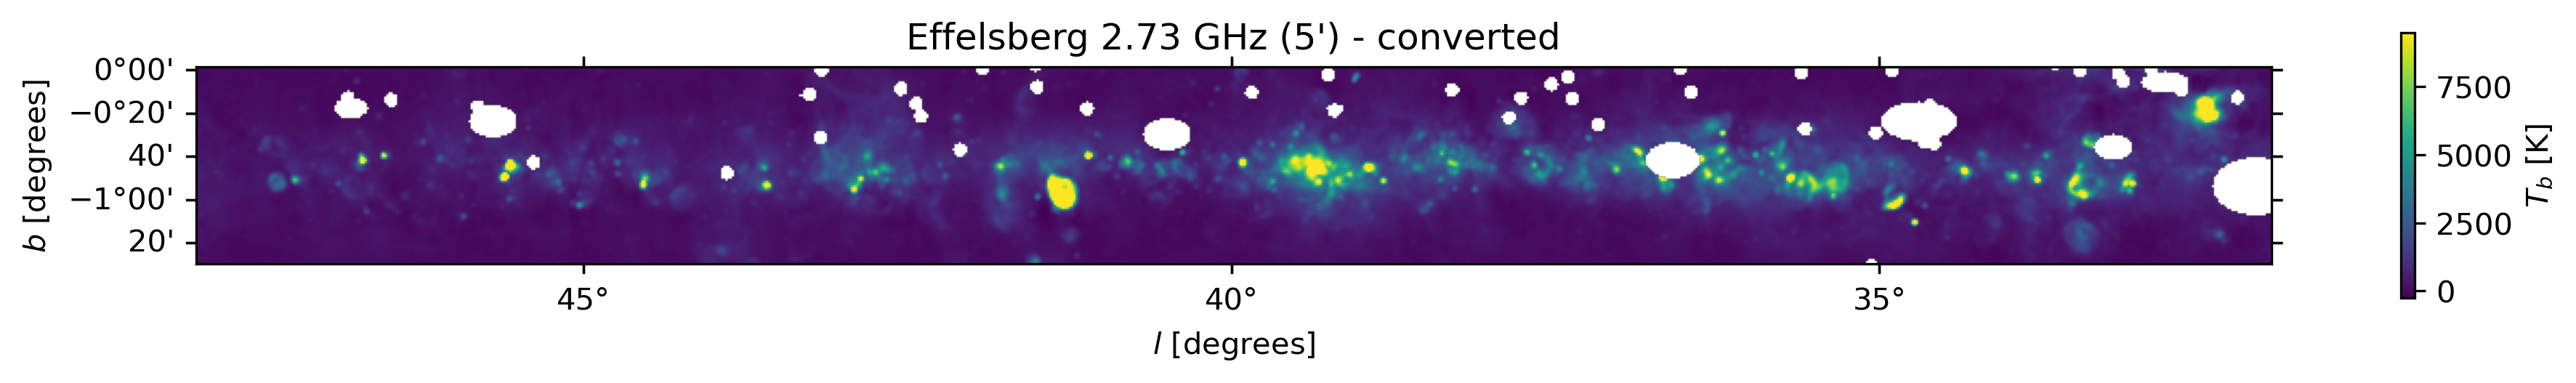

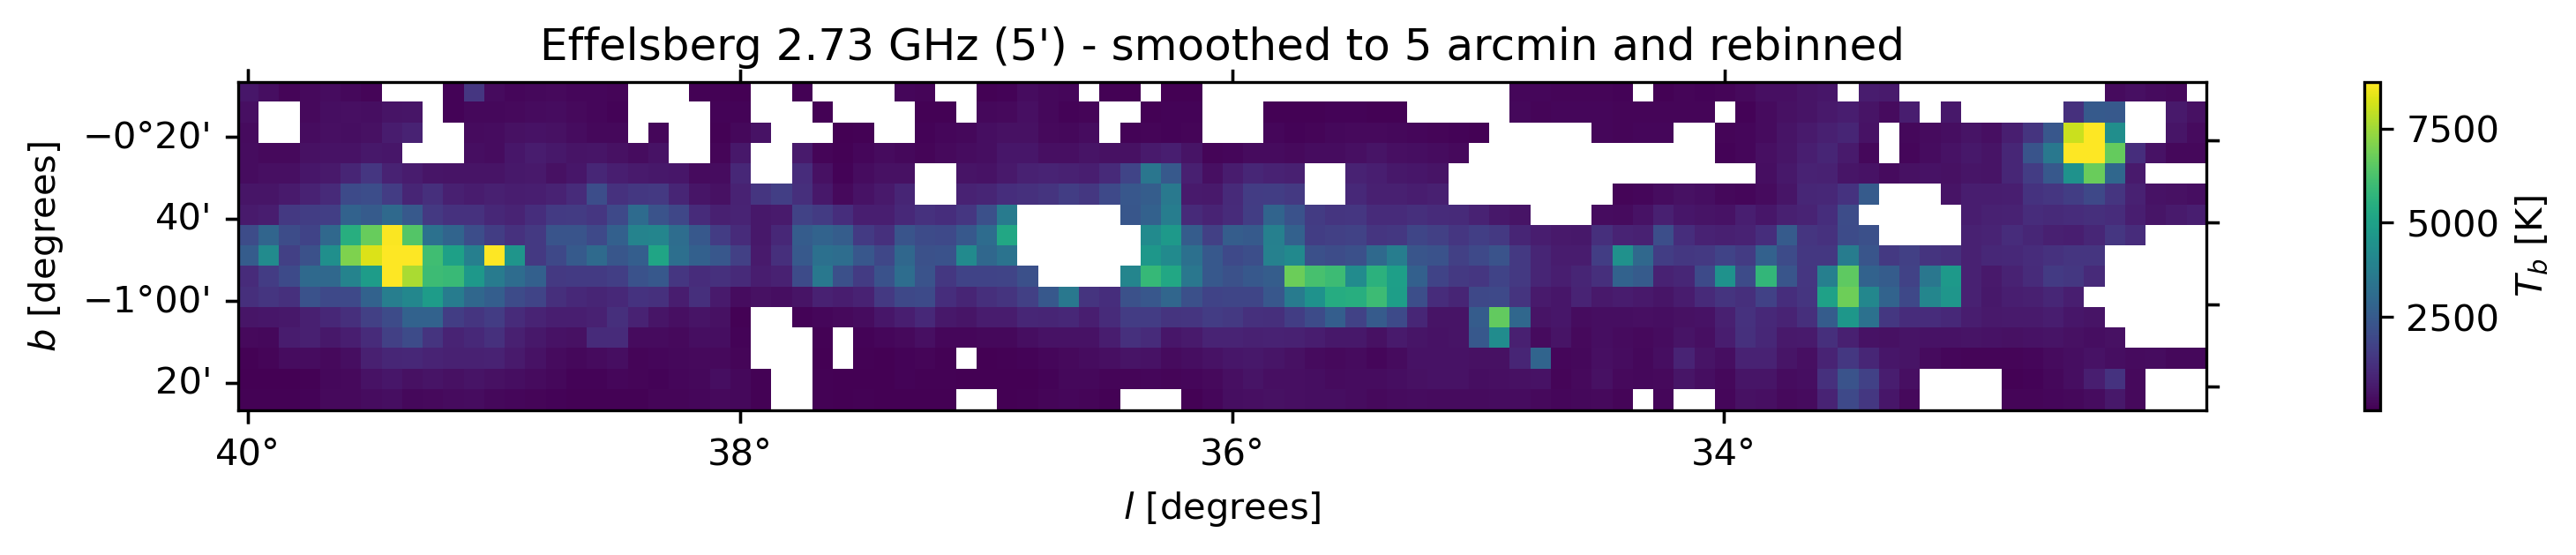

WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-CAR' 'GLAT-CAR' 
CRVAL : 90.0 0.0 
CRPIX : 5401.0 301.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0166666 0.0166666 
NAXIS : 10801  601


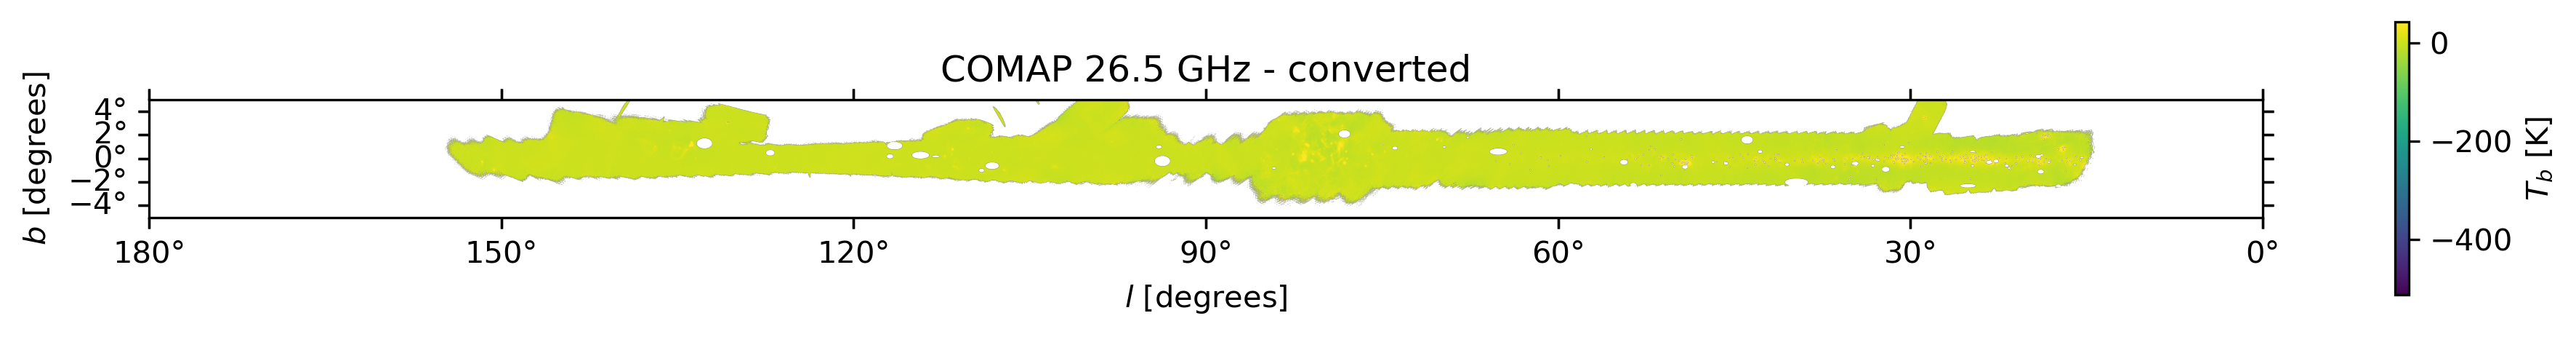

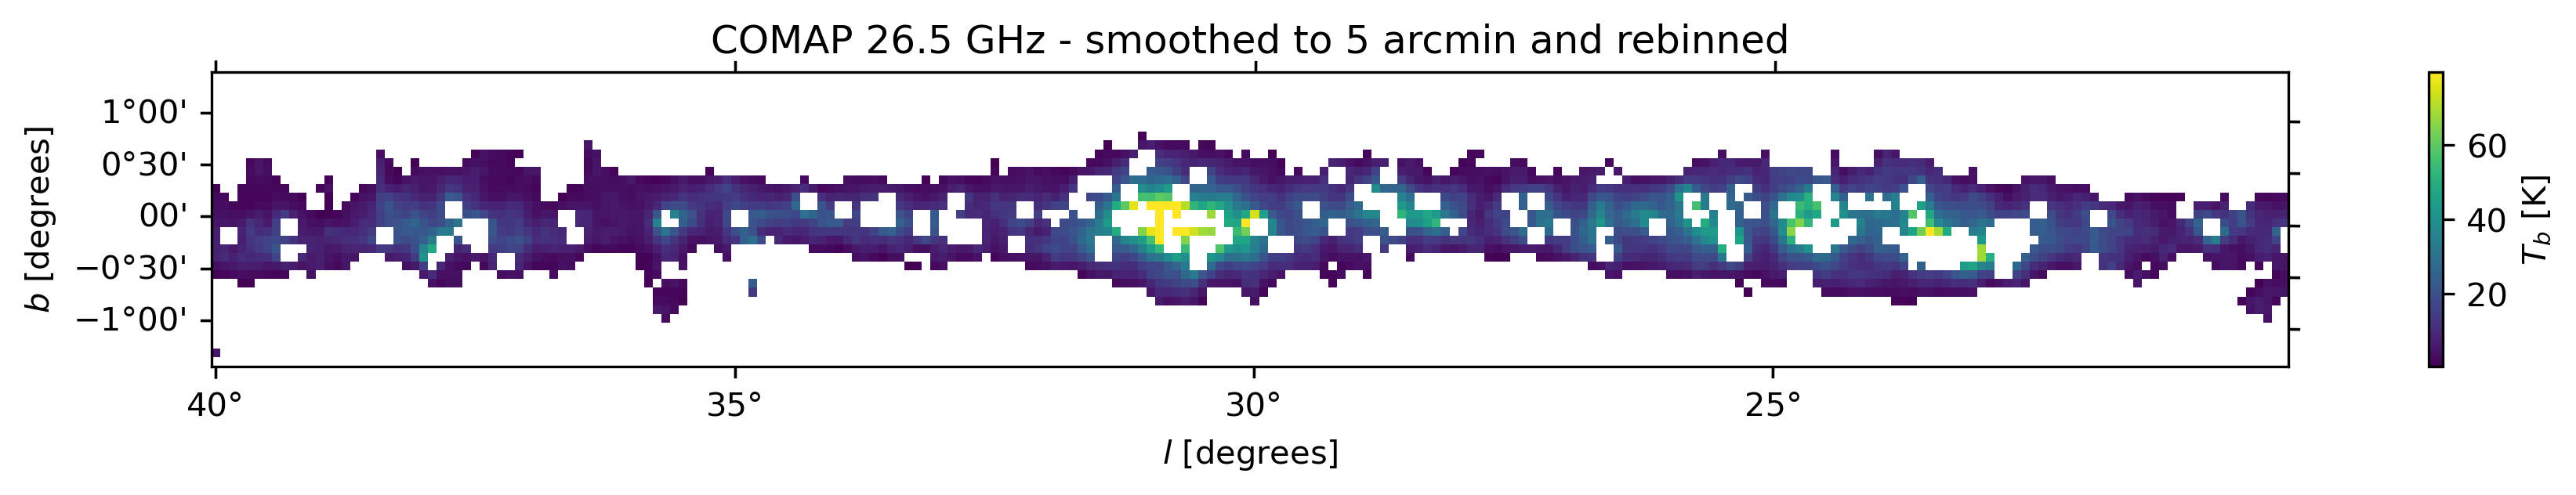

IndexError: boolean index did not match indexed array along axis 0; size of axis is 16 but size of corresponding boolean axis is 34

In [124]:
# --- MAIN CODE ---

map_titles = ( # add more as needed
    list(COMAP_MAPS.keys()) + 
    # ["COMAP 30.5 GHz"] +
    list(EFFELSBERG_MAPS.keys()) + 
    # list(GDIGS_MAPS.keys()) + 
    list(NOBEYAMA_MAPS.keys()) +
    # list(SINO_GERMAN_MAPS.keys()) 
    list(PARKES_MAPS.keys())
    # list(AMI_MAPS.keys())
    # list(AKARI_MAPS.keys())
)

# SPECIFIC PAIR OF MAPS

# map2_title = "COMAP 26.5 GHz"
# map1_title = "GDIGS Moment 0"
# # map1_title = "Effelsberg 2.73 GHz (5 amin)"

# main(map1_title, map2_title, show_plots=True)

# OR: LOOP ONE MAP OVER ALL OTHER MAPS
map1_title = "Effelsberg 2.73 GHz (5')"
# map1_title = "GDIGS Moment 0"

for i, map2_title in enumerate(map_titles):
    if map2_title != map1_title:
        main(map1_title, map2_title, show_plots=True)


# # OR: LOOP OVER ALL UNIQUE PAIRS OF MAPS (use with caution and clear output when done!)

# for i, map1_title in enumerate(map_titles):
#     for j, map2_title in enumerate(map_titles):
#         if i < j:
#             main(map1_title, map2_title, show_plots=True)

